# Adaptive ANC

Traditional ANC implementations rely on controllers with fixed parameters, which are typically optimized offline for a specific operating condition. While such systems can be effective in static or well-controlled environments, their performance degrades significantly in realistic scenarios. 

The motivation for building **adaptive** ANC systems stems from the limitations of ANC with fixed parameters which:
- struggle with dynamically changing noise environment,
- do not account for individual differences in ear shape or headphones fit. 

Adaptive ANC systems are designed to overcome these limitations by continuously **updating controller parameters during operation**. By exploiting real-time measurements of the residual noise, adaptive algorithms can track changes in acoustic paths and noise statistics. This results in more robust, consistent, and personalized noise cancellation performance across users and operating conditions.


## Adaptive feedforward ANC

Let us start with _feedforward_ ANC.

In a conventional single-channel feedforward ANC system, a reference microphone captures a signal correlated with the incoming noise before it reaches the listener. This reference signal is processed by an adaptive feedforward controller, which generates an anti-noise signal emitted by a loudspeaker.

An error microphone placed near the listener’s ear measures the residual noise resulting from a superposition of the primary noise and the generated anti-noise. This error signal serves two purposes: it quantifies the system’s performance and provides the feedback required to adapt the feedforward controller. The controller parameters are updated to minimize the measured error signal, thereby improving noise cancellation over time.

This adaptive structure enables the system to respond to time-varying noise fields and changing acoustic paths, making it well suited for real-world ANC applications such as headphones and vehicle cabins.

## Adaptive filters

_Adaptive filters_ ([AFs](https://en.wikipedia.org/wiki/Adaptive_filter)) constitute the fundamental building block of adaptive ANC systems. An adaptive filter automatically adjusts its coefficients to minimize a predefined error criterion, typically the _mean squared error_ (MSE) between its output and a desired signal. The adaptation is performed iteratively using optimization algorithms driven by observed data.

<center><img src="images/adaptive_filter.jpg" width="400"></center>

Among the many adaptive filtering algorithms, the _Least Mean Square_ (LMS) algorithm and its variants are particularly popular due to their simplicity and robustness. In ANC applications, the _Filtered-x Least Mean Square_ (FxLMS) algorithm is widely regarded as the standard approach. FxLMS modifies the classic LMS update rule to account for the presence of the secondary path between the controller output and the error microphone.

The original [LMS](https://en.wikipedia.org/wiki/Least_mean_squares_filter) and its variations, like FxLMS, can be seen as an instance of the _stochastic gradient descent_ algorithm. The algorithm updates the filter parameters by finding the gradient of the mean squared error, aiming at reducing this error.

### Frequency-domain AFs

While the original LMS and FxLMS algorithms operate in the time domain, _frequency-domain adaptive filters_ (FDAFs) offer several practical advantages, particularly for long filters and broadband noise. By transforming signals into the frequency domain using the fast Fourier transform (FFT), convolution operations are converted into element-wise multiplications, substantially reducing computational complexity.

In addition to improved efficiency, FDAFs enable more uniform and faster convergence by adapting step sizes independently across frequency bins. This feature is especially beneficial when the input signal exhibits strong spectral coloration, as it allows the algorithm to compensate for power imbalances across frequencies.


To demonstrate the essence of these algorithms, the following [FDAF](https://github.com/ewan-xu/pyaec/blob/main/frequency_domain_adaptive_filters/fdaf.py) implementation is borrowed from the [pyaec](https://github.com/ewan-xu/pyaec) repo:

```python
def fdaf(x, d, M, mu=0.05, beta=0.9):
    H = np.zeros(M+1, dtype=np.complex)
    norm = np.full(M+1, 1e-8)
    
    window =  np.hanning(M)
    x_old = np.zeros(M)
    
    num_block = min(len(x),len(d)) // M
    e = np.zeros(num_block * M)
    
    for n in range(num_block):
        x_n = np.concatenate([x_old, x[n*M:(n+1)*M]])
        d_n = d[n*M:(n+1)*M]
        x_old = x[n*M:(n+1)*M]
        
        X_n = fft(x_n)
        Y_n = H * X_n
        y_n = ifft(Y_n)[M:]
        e_n = y_n - d_n
        e[n*M:(n+1)*M] = e_n
        
        e_fft = np.concatenate([np.zeros(M), e_n*window])
        E_n = fft(e_fft)
        
        norm = beta * norm + (1-beta) * np.abs(X_n)**2
        G = E_n * X_n.conj() / (norm + 1e-3)
        H = H - mu * G
        
        h = ifft(H)
        h[M:] = 0
        H = fft(h)
    
    return e
```
This representative implementation illustrates the main ideas of FDAFs: time-domain signal frames are transformed into the frequency domain, filtered via element-wise multiplication, and transformed back to compute the error signal.

It corresponds to the following scheme from the well-known [overview of FDAFs](https://people.isy.liu.se/rt/fredrik/spcourse/multirate.pdf):

<center><img src="images/multirate-fig5.png" width="800"></center>

In this code, variables with lower-case letters correspond to the time domain, and variables with capital letters correspond to the frequency domain. For instance, `H = fft(h)` is the frequency response of the adaptive filter defined by its impulse response `h`. Furthermore, the filtered signal frame, `y_n = ifft(fft(x_n) * fft(h))`, is computed as an elementwise multiplication of in the frequency domain before transforming back to the time domain.

By definition, the error frame `e_n` is computed as a difference between a desired signal `d_n` and a filter output `y_n`. Using frequency-domain representations, it can be written as:

$\mathrm{E} = \mathrm{H} \cdot \mathrm{X} - \mathrm{D}$

The objective function minimized by the AF is the MSE:

$L = \frac{1}{2}||\mathrm{E}||^2$

(We assume a finite signal and omit the expectation operator for simplicity of presentation)

Its gradient `G` wrt to the filter paramters $\mathrm{H}$ is given by the expression:

$\nabla L = \mathrm{G} = \mathrm{E} \cdot \mathrm{X}^H$

Further, the filter `H` is updated by the gradient descent step with _learning rate_ `mu`:

$\mathrm{H} = \mathrm{H} - \mu \cdot \mathrm{G}$

Since the implemented algorithm is actually the [NLMS](https://en.wikipedia.org/wiki/Least_mean_squares_filter#Normalized_least_mean_squares_filter_(NLMS))
 (rather than the classic LMS), it includes an additional normalization operation with `norm` being the power of the input frame.


## AFs for adaptive ANC

In the context of ANC, the target signal is the noise propagated through the _primary path_ (PP): $\mathrm{D} = \mathrm{PP} \cdot \mathrm{X}$, - such that the $\mathrm{PP}$ is a plant to be identified. 

A key distinction from classical adaptive filtering arises due to the presence of the _secondary path_ (SP), which represents the transfer function between the controller output and the error microphone. The anti-noise generated by the adaptive filter is modified by the secondary path before it combines with the primary noise. Consequently, the adaptive filter must implicitly account for both the primary and secondary paths during adaptation.

<center><img src="images/af_anc.png" width="500"></center>


### FDAF based adaptive ANC

Here, we will describe a solution for an adaptive ANC based on FDAF.

In ANC, the error signal is a sum of the primary noise and the generated "_anti-noise_" signal: 

$\mathrm{E} = \mathrm{PP} \cdot \mathrm{X} + \mathrm{SP} \cdot \mathrm{FF} \cdot \mathrm{X}$

(NOTE: here, $\mathrm{FF}$ represent the filter frequency response and corresponds to `H` in the code above)

The gradient of the MSE therefore includes the frequency response of the secondary path:

$\nabla L = \mathrm{E} \cdot (\mathrm{SP} \cdot \mathrm{X})^H$

and the update rule for the FF filter becomes:

$\mathrm{FF}_{i+1} = \mathrm{FF}_i - \mu \cdot \nabla L = \mathrm{FF}_i - \mu \cdot \mathrm{E} \cdot (\mathrm{SP} \cdot \mathrm{X})^H$

One can note that, unlike $\mathrm{E}$ and $\mathrm{X}$, the transfer function of the secondary path, $\mathrm{SP}$, is unknown. This requires estimating the $\mathrm{SP}$ either offline or online, or replacing it by an average model assumed to be sufficiently accurate for adaptation purposes.

NOTE: in adaptive ANC, to eliminate the delay of FDAFs, filtering is perfromed in the time domain (sample-by-sample) while the filter itself is updated in the frequency domain.

### Alternative update rules

Beyond gradient descent-based algorithms, alternative adaptation rules can be derived. For example, one may formulate the requirement that the error signal should be driven to zero at the next iteration:

$\mathrm{E} = \mathrm{D} + \mathrm{SP} \cdot \mathrm{FF}_i \cdot \mathrm{X}$

$\mathrm{0} = \mathrm{D} + \mathrm{SP} \cdot \mathrm{FF}_{i+1} \cdot \mathrm{X}$

This yields a different update rule:

$\mathrm{FF}_{i+1} = \mathrm{FF}_i - \frac{\mathrm{E}}{\mathrm{SP} \cdot \mathrm{X}} = \mathrm{FF}_i - \frac{\mathrm{E} \cdot (\mathrm{SP} \cdot \mathrm{X})^H}{|\mathrm{SP}|^2 \cdot |\mathrm{X}|^2}$ 

Since the MSE cost function is quadratic in the filter parameters, this approach naturally leads to update rules analogous to those obtained via [Newton's method](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization).


### Extensions to hybrid ANC

In practical ANC systems, where an additional _feedback_ (FB) controller is usually present, the adaptation rules must be modified to account for the combined effect of FF and FB controllers.

Starting from the error signal

$\mathrm{E} = \frac{\mathrm{PP} \cdot \mathrm{X} + \mathrm{SP} \cdot \mathrm{FF} \cdot \mathrm{X}}{1 + \mathrm{SP} \cdot \mathrm{FB}}$

and following the same derivation principles as above, the update rule for the $\mathrm{FF}$ frequency response is given by:

$\mathrm{FF}_{i+1} = \mathrm{FF}_i - \frac{\mathrm{E} \cdot \mathrm{X}^H}{\mathrm{SP} \cdot |\mathrm{X}|^2} \cdot (1 + \mathrm{SP} \cdot \mathrm{FB}) = \mathrm{FF}_i - \frac{\mathrm{E} \cdot \mathrm{X}^H}{\mathrm{SP}_\text{fb} \cdot |\mathrm{X}|^2} $,

where $\mathrm{SP}_\text{fb} = \frac{\mathrm{SP}}{1 + \mathrm{SP} \cdot \mathrm{FB}}$ is the SP transfer function that includes feedback effects.

In the absence of FB controller, ($\mathrm{FB} = 0$), these expressions reduce to the standard feedforward update rules, ensuring consistency with earlier formulations.

Similarly, in the case of gradient descent, a modified update rule can be obtained by replacing $\mathrm{SP}$ by $\mathrm{SP}_\text{fb}$.


### Practical implementation with biquad filters

In real-world ANC products, controllers are often implemented as cascades of _biquadratic filters_ ([biquads](https://en.wikipedia.org/wiki/Digital_biquad_filter)) filters rather than arbitrary finite impulse response (FIR) filters. This introduces an additional constraint on the adaptation process, as the controller must remain within the space of realizable biquad parameterizations.

Two main strategies can be employed to address this constraint. 

- The first approach performs adaptation directly in the space of biquad parameters, which can be challenging due to nonlinearity and parameter coupling.
  
- The second approach updates a target frequency response using classic adaptive filtering algorithms and then projects this response back onto the space of feasible biquad cascades after each adaptation step.

Here, we follow the second approach: after each step, the updated frequency response is projected back to the space of possible biquad cascades. In addition, the projection-based algorithms relies on the assumption that parameter updates between iterations are small. Under this assumption, the optimization can track the desired frequency response closely without becoming trapped in poor local optima.

The resulting procedure resembles [coordinate descend](https://en.wikipedia.org/wiki/Coordinate_descent) with fixed step sizes. In detail, the algorithm finds the descent direction along a signle coordinate and makes a **fixed** step in this direction. The step sizes are tuned in advance based on a trade-off between the performance and stability.


## Adaptive ANC with virtual sensing

In many practical ANC applications, the location at which noise reduction is desired does not coincide with the location where a physical error microphone can be placed. This situation arises frequently in applications such as:

- headphone or hearable ANC, where the desired quiet zone is at the eardrum;
- industrial or automotive ANC, where microphones cannot be placed at the true control point for safety or ergonomic reasons;
- spatial ANC problems involving large quiet zones or inaccessible locations.

Let us introduce a few terms:

The _error reference point_ (ERP) as the physical location where the error microphone is installed;

The _drum reference point_ (DRP) as the location where noise cancellation is actually desired (aka _virtual microphone_).

<center><img src="images/virtual.png" width="600"></center>

While significant attenuation may be achieved at the physical error sensor (microphone) location, the zone of quiet tends to be too small to extend to the desired location (eardrum). To this end, a number of _virtual sensing_ algorithms have been developed to shift the zone of quiet to a desired location (DRP) that is remote from the physical sensor (ERP). Using the physical error signal, a virtual sensing algorithm is used to estimate the pressure at a fixed virtual location. Then, instead of minimising the physical error signal, the estimated pressure is minimised with the ANC system to generate a zone of quiet at the virtual location. 

<center><img src="images/Remote-ANC-system.png" width="400"></center>

To summarize, the objective of virtual sensing is to estimate or reconstruct the error signal at the DRP using measurements available at the ERP, and to use this estimate to drive the adaptive ANC algorithm.





### Remote micropthone method

The _Remote Microphone_ (RM) method is based on the assumption that the acoustic fields at the ERP and DRP are linearly related. Under this assumption, the primary noise at the DRP can be estimated from measurements at the ERP using a transfer function $\mathrm{C}$:

$\mathrm{D}_\text{DRP} = \mathrm{C} \cdot \mathrm{D}_\text{ERP}$

The transfer function $\mathrm{C}$ is typically identified offline during a calibration phase, when the control source is inactive.

During active control, the same linear relationship is assumed to hold for the total error signals. The virtual error at the DRP is approximated as:

$\mathrm{E}_\text{DRP} \approx \mathrm{C} \cdot \mathrm{E}_\text{ERP}$

This estimate is then used as the error signal for adaptation of the feedforward controller, replacing the physically measured error at the ERP.

The RM method relies on several important assumptions:

- Linear spatial relationship. The acoustic transfer from ERP to DRP must be well approximated by a linear, time-invariant system.

- Control-independent mapping. The transfer function $C$ is assumed to be valid both during calibration (no control) and during active control.

Since the secondary-path contributions are not explicitly modeled, the RM method may become inaccurate when the control source significantly alters the sound field. As a result, RM-based virtual sensing is simple and computationally efficient, but its performance can degrade when the spatial relationship between ERP and DRP varies or when strong control signals are present.


### Auxiliary filter method

The _Auxiliary Filter_ (AF) method explicitly incorporates both the primary and secondary paths at the DRP. Instead of directly mapping the error signal, the method introduces an auxiliary filter that reshapes the error signal at the ERP so that it approximates the error at the DRP. This approach is more physically grounded than the RM method and typically provides improved accuracy.

If a physical error microphone were available at the DRP, perfect cancellation would require the error signal to be zero. Solving for the ideal feedforward controller yields:

$\mathrm{FF}_\text{DRP} = - \frac{\mathrm{PP}_\text{DRP}}{\mathrm{SP}_\text{DRP}}$

This filter represents the ideal feedforward controller that would achieve perfect cancellation at the DRP if implemented exactly. It is estimated at the tuning stage.

Since the ANC system adapts based on the error measured at the ERP, the AF method modifies this error signal to compensate for the mismatch between ERP and DRP.

Let us define the _auxiliary filter_ transfer function that can be also estimated during the tuning stage:

$\mathrm{H} = \mathrm{PP}_\text{ERP} - \mathrm{SP}_\text{ERP} \cdot \mathrm{FF}_\text{DRP}$

Using this definition, the error signal is adjusted as follows:

$\mathrm{E}_\text{af} = \mathrm{E} - \mathrm{H} \cdot \mathrm{X}$

The auxiliary error signal replaces the physical error signal in the adaptive algorithm. This ensures that adaptation is driven by an error criterion that is equivalent to minimizing the true error at the DRP.

Substituting $\mathrm{E} = \mathrm{PP}_\text{ERP} \cdot \mathrm{X} + \mathrm{SP}_\text{ERP} \cdot \mathrm{FF} \cdot \mathrm{X}$, we obtain:

$\mathrm{E}_\text{af} = \mathrm{SP}_\text{ERP} \cdot (\mathrm{FF} - \mathrm{FF}_\text{DRP}) \cdot \mathrm{X}$

Thus, minimizing $\mathrm{E}_\text{af}$ forces the FF controller to converge towards $\mathrm{FF}_\text{DRP}$, which corresponds to the optimal cancellation at the DRP.

### Summary

Virtual sensing enables adaptive feedforward ANC systems to minimize noise at locations where physical microphones cannot be placed. The RM method provides a simple, calibration-based solution that maps measured error signals to a remote location, while the AF method offers a more rigorous and physically grounded approach by explicitly incorporating primary and secondary path models at the desired control point.

In practice, the choice between RM and AF methods involves a trade-off between implementation complexity and control accuracy. 

See the studies [1](https://eprints.soton.ac.uk/484142/1/ICCAIS_Kaji_Submission.pdf) and [2](https://www.sciencedirect.com/science/article/abs/pii/S0003682X25002804) for related discussions

...WORK IN PROGRESS...

In [1]:
import os, sys

import numpy as np
import matplotlib.pyplot as plt

from types import SimpleNamespace

In [2]:
from scipy.signal import freqz, lfilter, sosfreqz, sosfilt, coherence
import librosa
import yaml

In [3]:
project_root = "."

In [4]:
from dsp import resample, mag2db
from dsp.filters import freqz, sosfreqz
from dsp import load_fir, load_sos
from dsp import attenuation, rel_diff_db
from dsp import spectral_args

from models.parametrization import ParametrizationEQ

In [5]:
firfilt = lambda kernel, x: lfilter(kernel, 1, x)

In [6]:
def weighting_bell(n):
    from common.math import bell_curve
    pdf = bell_curve(n)
    pdf = pdf / pdf.max()
    return pdf

In [8]:
from adafilt.fdaf import fdaf
from optim.algos import step_fixed

In [9]:
fs = 192000 # sampling rate

In [10]:
with open(f"{project_root}/meta.yaml") as f:
    meta = yaml.safe_load(f)

Load PP and SP impulse responses

In [11]:
dataset_path = meta["datasets"]["PANDAR"]

fs_data = 48000

path_pp = f"{dataset_path}/PP/PP_PersonID1_L_normal.txt"
path_sp = f"{dataset_path}/SP/SP_PersonID1_L_normal.txt"

# path_pp = f"{dataset_path}/PP/PP_PersonID7_L_normal.txt"
# path_sp = f"{dataset_path}/SP/SP_PersonID7_L_normal.txt"

# path_pp = f"{dataset_path}/PP/PP_PersonID11_R_slightly-loose.txt"
# path_sp = f"{dataset_path}/SP/SP_PersonID11_R_slightly-loose.txt"

# path_pp = f"{dataset_path}/PP/PP_PersonID12_L_loose.txt"
# path_sp = f"{dataset_path}/SP/SP_PersonID12_L_loose.txt"


PP_48k = load_fir(path_pp)
SP_48k = load_fir(path_sp)

PP = resample(PP_48k, fs=fs_data, fs_new=fs)
SP = resample(SP_48k, fs=fs_data, fs_new=fs)

Generate artificial data for simulation

In [12]:
duration = 5.0 # sec

length = int(duration * fs)

In [13]:
np.random.seed(42)

ref = np.random.randn(length) # external noise measured by the reference microphone

noise = np.random.randn(*ref.shape) * 0.03 # uncorrelated noise: nonlinear effects, sensor noise, etc

erp = firfilt(PP, ref) + noise # external noise propagated through the primary path

ref_sp = firfilt(SP, ref) # SP-filtered reference signal

The FF filter is implemented using a cascade of biquads, where
each biquad corresponds to a _parametric equalizer_ (PEQ) such as shelving, peaking, or high/low-pass filter. 

<center><img src="https://christiangaertner.github.io/uhh-digitalaudioprocessing/assets/img/FilterTypes.png" width="500"></center>

Each of these filters is parameterized by three variables: _frequency_ (f), _gain_ (g), and _quality factor_ (Q).

In [14]:
ftypes = ["ls", "hs", "pk", "pk", "pk", "pk", "pk"]
n_sections = len(ftypes)
parametrization = ParametrizationEQ(n_sections, ftypes, fs=fs)

# load a pre-trained FF filter
FF_bq = parametrization.load(f"{project_root}/results/ff_raw.yaml")
FF_sos = parametrization.decode(FF_bq)

Compute the error signal and estimate the relative attenuation (dB)

In [15]:
erp_ff = sosfilt(FF_sos, ref_sp)

error_ff = erp_ff - erp
f, att_ff = attenuation(error_ff, erp, **spectral_args)

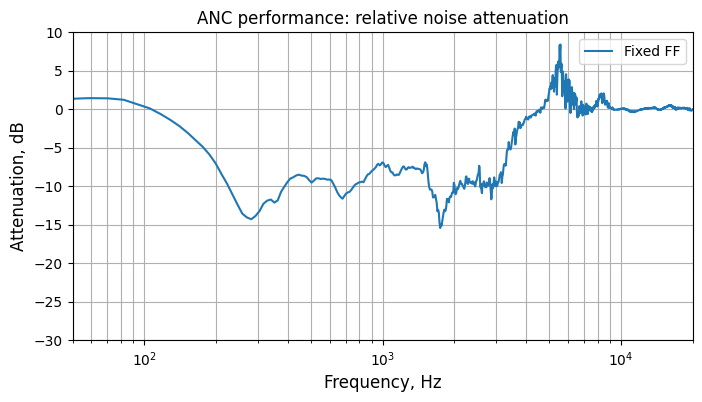

In [16]:
plt.figure(figsize=(8, 4));

plt.semilogx(f, att_ff, label="Fixed FF");

plt.grid(which="both");
plt.xlim(50, 20000);
plt.ylim(-30, 10);
plt.legend();
plt.title("ANC performance: relative noise attenuation");
plt.xlabel("Frequency, Hz", fontsize=12);
plt.ylabel("Attenuation, dB", fontsize=12);

For the coordinate descent like algorithm, used to approximate the adapted frequency response, we use different step sizes for each category of PEQ parameters (f, Q, g)

In [17]:
np.random.seed(42)

config = SimpleNamespace()

config.decode = lambda x: parametrization.decode(x)

step_mask = np.ones(n_sections)
step = np.kron([5e-1, 1e-5, 1e-4], step_mask)
config.step = step

bounds_global = parametrization.bounds()
bounds = parametrization.bounds()

# optional: avoid changing the sign of the initial parameter
for i in range(len(FF_bq)):
    low, up = bounds_global[i]
    if FF_bq[i] < 0:
        bounds[i] = (low, min(0, up))
    else:
        bounds[i] = (max(0, low), up)
        
config.bounds = bounds

Here, we consider an **idealized case** where the SP model, used by the adaptive filter, is equal to the actual SP. This allows to apply the SP filter to the reference signal in advance, and use it as an inout to the adaptive filter.

In [18]:
frame_size = 1024
mu = 0.9
beta = 0.1

n_fft = frame_size + 1

mask_freq_upd = np.zeros(n_fft)
freq_band_idx = int((8000 / fs) * n_fft)
mask_freq_upd[:freq_band_idx] = weighting_bell(freq_band_idx)

mu = mu * mask_freq_upd


# set up a filter structure with the following methods:
# .freqz() - return the frequensy response
# .apply() - filter a signal
# .fit_freqz() - approximate the target frequensy response
filter = SimpleNamespace()

n_fft = frame_size + 1
freqz_fn = lambda bq: sosfreqz(parametrization.decode(bq), worN=n_fft, fs=fs, log=False)
filter.freqz = freqz_fn

filter_fn = lambda bq, x: sosfilt(parametrization.decode(bq), x)
filter.apply = filter_fn

def _fit_freqz(bq, H_target, freqz_fn, diff_fn, opt_cfg):
    loss_fn = lambda bq: diff_fn(freqz_fn(bq)[1], H_target)    
    for _ in range(opt_cfg.n_steps):
        bq = step_fixed(bq, loss_fn, opt_cfg)
    return bq

freq_band_idx = int((6000 / fs) * n_fft)
weighting = weighting_bell(freq_band_idx)
diff_fn = lambda x, y: rel_diff_db(x, y, weighting)

config.n_steps = 1
config.step_size_max = 1
config.n_steps_linesearch = 16
fit_freqz_fn = lambda bq, H_target: _fit_freqz(bq, H_target, freqz_fn, diff_fn, config)
filter.fit_freqz = fit_freqz_fn


FF_bq_ada = FF_bq.copy()

n_repeats = 3
for _ in range(n_repeats):
    erp_ff_ada_, FF_bq_ada = fdaf(ref_sp, erp, frame_size, filter, FF_bq_ada, mu, beta)

100%|█████████████████████████████████████████| 937/937 [00:23<00:00, 40.70it/s]


To demonstrate the ANC performance **before** and **after adaptation**, we will compute the relative attenuation using a fixed filter - the result of the adaptation procedure

In [19]:
FF_sos_ada = parametrization.decode(FF_bq_ada)
erp_ff_ada = sosfilt(FF_sos_ada, ref_sp) # after convergence !

In [20]:
error_ff_ada = erp_ff_ada - erp
f, att_ff_ada = attenuation(error_ff_ada, erp, **spectral_args)

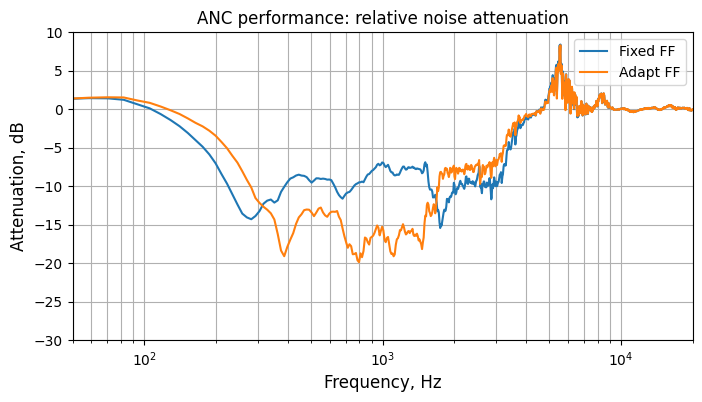

In [21]:
plt.figure(figsize=(8, 4));

plt.semilogx(f, att_ff, label="Fixed FF");
plt.semilogx(f, att_ff_ada, label="Adapt FF");

plt.grid(which="both");
plt.xlim(50, 20000);
plt.ylim(-30, 10);
plt.legend();
plt.title("ANC performance: relative noise attenuation");
plt.xlabel("Frequency, Hz", fontsize=12);
plt.ylabel("Attenuation, dB", fontsize=12);

The resulting attenuation improvment is not uniform, so the algorithm requires further tuning...